In [2]:
#Importamos librerias
from statsbombpy import sb
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch, VerticalPitch, Sbapi

In [3]:
#Cargamos las competiciones disponibles
competitions = sb.competitions()
competitions.head()

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-07-15T14:15:54.671676,2024-07-15T14:17:00.877356,2024-07-15T14:17:00.877356,2024-07-15T14:15:54.671676
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,None,None,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2024-06-13T07:51:02.452825,None,None,2024-06-13T07:51:02.452825
3,16,4,Europe,Champions League,male,False,False,2018/2019,2024-06-12T07:44:38.559714,2021-06-13T16:17:31.694,None,2024-06-12T07:44:38.559714
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,None,2024-02-13T02:35:28.134882


In [4]:
competitions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   competition_id             74 non-null     int64 
 1   season_id                  74 non-null     int64 
 2   country_name               74 non-null     object
 3   competition_name           74 non-null     object
 4   competition_gender         74 non-null     object
 5   competition_youth          74 non-null     bool  
 6   competition_international  74 non-null     bool  
 7   season_name                74 non-null     object
 8   match_updated              74 non-null     object
 9   match_updated_360          56 non-null     object
 10  match_available_360        10 non-null     object
 11  match_available            74 non-null     object
dtypes: bool(2), int64(2), object(8)
memory usage: 6.1+ KB


In [5]:
competitions['competition_name'].unique()

array(['1. Bundesliga', 'African Cup of Nations', 'Champions League',
       'Copa America', 'Copa del Rey', "FA Women's Super League",
       'FIFA U20 World Cup', 'FIFA World Cup', 'Indian Super league',
       'La Liga', 'Liga Profesional', 'Ligue 1', 'Major League Soccer',
       'North American League', 'NWSL', 'Premier League', 'Serie A',
       'UEFA Euro', 'UEFA Europa League', "UEFA Women's Euro",
       "Women's World Cup"], dtype=object)

In [6]:
competitions['country_name'].unique()

array(['Germany', 'Africa', 'Europe', 'South America', 'Spain', 'England',
       'International', 'India', 'Argentina', 'France',
       'United States of America', 'North and Central America', 'Italy'],
      dtype=object)

In [7]:
competitions[['season_id','competition_id','season_name']][competitions['competition_name']=='FIFA World Cup']

,season_id,competition_id,season_name
29,106,43,2022
30,3,43,2018
31,55,43,1990
32,54,43,1986
33,51,43,1974
34,272,43,1970
35,270,43,1962
36,269,43,1958


In [8]:
# Partidos de la competicion
matches = sb.matches(competition_id=43, season_id=106)
matches.sort_values(by='match_date')

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,...,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
35,3857286,2022-11-20,18:00:00.000,International - FIFA World Cup,2022,Qatar,Ecuador,0,2,available,...,2023-07-25T07:19:21.209321,1,Group Stage,Al Bayt Stadium,Daniele Orsato,Félix Sánchez Bas,Gustavo Julio Alfaro,1.1.0,2,2
57,3857271,2022-11-21,15:00:00.000,International - FIFA World Cup,2022,England,Iran,6,2,available,...,2023-06-18T15:37:14.539174,1,Group Stage,Sheikh Khalifa International Stadium,Raphael Claus,Gareth Southgate,Carlos Manuel Brito Leal Queiróz,1.1.0,2,2
46,3857285,2022-11-21,18:00:00.000,International - FIFA World Cup,2022,Senegal,Netherlands,0,2,available,...,2023-06-20T10:37:16.264240,1,Group Stage,Al Thumama Stadium,Wilton Pereira Sampaio,Aliou Cissé,Louis van Gaal,1.1.0,2,2
34,3857282,2022-11-21,21:00:00.000,International - FIFA World Cup,2022,United States,Wales,1,1,available,...,2023-07-25T09:10:59.976019,1,Group Stage,Ahmad bin Ali Stadium,Abdulrahman Ibrahim Al Jassim,Gregg Berhalter,Robert Page,1.1.0,2,2
63,3857254,2022-11-22,15:00:00.000,International - FIFA World Cup,2022,Denmark,Tunisia,0,0,available,...,2023-07-29T19:44:56.738444,1,Group Stage,Education City Stadium,César Arturo Ramos Palazuelos,Kasper Hjulmand,Jalel Kadri,1.1.0,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8,3869486,2022-12-10,17:00:00.000,International - FIFA World Cup,2022,Morocco,Portugal,1,0,available,...,2023-04-26T23:03:02.645780,5,Quarter-finals,Al Thumama Stadium,Facundo Tello Figueroa,Hoalid Regragui,Fernando Manuel Fernandes da Costa Santos,1.1.0,2,2
19,3869519,2022-12-13,21:00:00.000,International - FIFA World Cup,2022,Argentina,Croatia,3,0,available,...,2023-04-26T22:32:37.808359,6,Semi-finals,Lusail Stadium,Daniele Orsato,Lionel Sebastián Scaloni,Zlatko Dalić,1.1.0,2,2
21,3869552,2022-12-14,21:00:00.000,International - FIFA World Cup,2022,France,Morocco,2,0,available,...,2023-04-26T22:30:45.010084,6,Semi-finals,Al Bayt Stadium,César Arturo Ramos Palazuelos,Didier Deschamps,Hoalid Regragui,1.1.0,2,2
18,3869684,2022-12-17,17:00:00.000,International - FIFA World Cup,2022,Croatia,Morocco,2,1,available,...,2023-04-26T22:18:59.308194,7,3rd Place Final,Sheikh Khalifa International Stadium,Abdulrahman Ibrahim Al Jassim,Zlatko Dalić,Hoalid Regragui,1.1.0,2,2


In [9]:
#Elegimos un partido
partido = sb.events(match_id=3869685)

In [10]:
partido.columns

Index(['50_50', 'bad_behaviour_card', 'ball_receipt_outcome',
       'ball_recovery_offensive', 'ball_recovery_recovery_failure',
       'block_deflection', 'block_offensive', 'carry_end_location',
       'clearance_aerial_won', 'clearance_body_part', 'clearance_head',
       'clearance_left_foot', 'clearance_other', 'clearance_right_foot',
       'counterpress', 'dribble_nutmeg', 'dribble_outcome', 'dribble_overrun',
       'duel_outcome', 'duel_type', 'duration', 'foul_committed_advantage',
       'foul_committed_card', 'foul_committed_offensive',
       'foul_committed_penalty', 'foul_committed_type', 'foul_won_advantage',
       'foul_won_defensive', 'foul_won_penalty', 'goalkeeper_body_part',
       'goalkeeper_end_location', 'goalkeeper_outcome', 'goalkeeper_position',
       'goalkeeper_technique', 'goalkeeper_type', 'id', 'index',
       'interception_outcome', 'location', 'match_id', 'minute', 'off_camera',
       'out', 'pass_aerial_won', 'pass_angle', 'pass_assisted_shot_id'

In [11]:
partido.head()

,50_50,bad_behaviour_card,ball_receipt_outcome,ball_recovery_offensive,ball_recovery_recovery_failure,block_deflection,block_offensive,carry_end_location,clearance_aerial_won,clearance_body_part,...,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 433, 'lineup': [{'player': {'id'...",Argentina,779,00:00:00.000,Starting XI,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 4231, 'lineup': [{'player': {'id...",France,771,00:00:00.000,Starting XI,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,France,771,00:00:00.000,Half Start,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Argentina,779,00:00:00.000,Half Start,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,France,771,00:00:00.000,Half Start,NaN


In [12]:
partido['player'].value_counts()

player
Enzo Fernandez                     328
Rodrigo Javier De Paul             242
Lionel Andrés Messi Cuccittini     242
Nicolás Hernán Otamendi            215
Jules Koundé                       211
Aurélien Djani Tchouaméni          205
Cristian Gabriel Romero            203
Dayotchanculle Upamecano           198
Alexis Mac Allister                196
Raphaël Varane                     182
Adrien Rabiot                      176
Nicolás Alejandro Tagliafico       165
Julián Álvarez                     150
Kylian Mbappé Lottin               149
Theo Bernard François Hernández    145
Nahuel Molina Lucero               142
Ángel Fabián Di María Hernández    132
Randal Kolo Muani                  127
Marcus Thuram                      119
Marcos Javier Acuña                112
Antoine Griezmann                  103
Hugo Lloris                         97
Kingsley Coman                      85
Damián Emiliano Martínez            83
Eduardo Camavinga                   83
Gonzalo Ariel Mont

In [13]:
messi = partido[partido['player']=='Lionel Andrés Messi Cuccittini']
messi

,50_50,bad_behaviour_card,ball_receipt_outcome,ball_recovery_offensive,ball_recovery_recovery_failure,block_deflection,block_offensive,carry_end_location,clearance_aerial_won,clearance_body_part,...,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Argentina,779,00:02:16.985,Pass,True
39,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Argentina,779,00:02:27.185,Pass,NaN
52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Argentina,779,00:03:52.966,Pass,NaN
62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Argentina,779,00:04:26.443,Pass,NaN
103,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Argentina,779,00:07:11.325,Pass,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4321,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Argentina,779,00:13:25.248,Dispossessed,True
4357,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Argentina,779,00:27:10.048,Injury Stoppage,NaN
4363,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Argentina,779,00:28:11.248,Player Off,NaN
4364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Argentina,779,00:28:19.983,Player On,NaN


In [14]:
messi[['x','y']]=messi['location'].apply(pd.Series)
messi_loc = messi[['x','y']]
messi_loc

C:\Users\gilda\AppData\Local\Temp\ipykernel_3748\619702276.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  messi[['x','y']]=messi['location'].apply(pd.Series)
C:\Users\gilda\AppData\Local\Temp\ipykernel_3748\619702276.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  messi[['x','y']]=messi['location'].apply(pd.Series)


,x,y
36,76.6,35.7
39,99.3,57.3
52,67.9,59.0
62,81.8,65.2
103,39.2,48.1
...,...,...
4321,96.1,45.1
4357,NaN,NaN
4363,NaN,NaN
4364,NaN,NaN


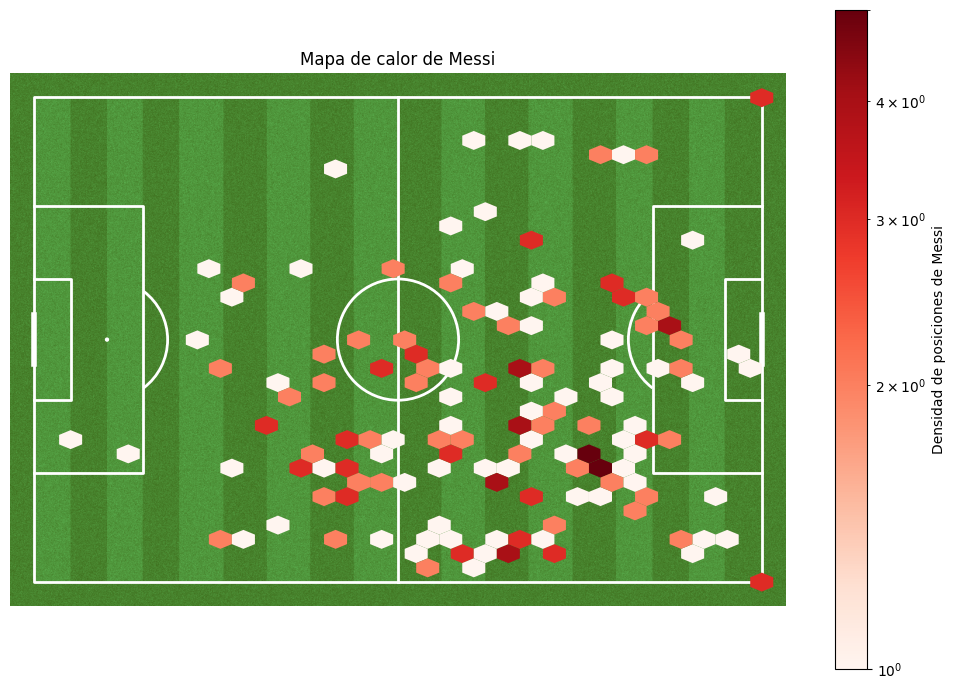

In [15]:
pitch = Pitch(pitch_type='statsbomb',pitch_color='grass', line_color='white',
              stripe=True)  # optional stripes
fig, ax = pitch.draw(figsize=(10, 7))
# Mapa de calor tipo hexbin
hb = ax.hexbin(messi_loc['x'], messi_loc['y'], gridsize=30, cmap='Reds', bins='log', edgecolors='none')

# Agregar colorbar
cb = fig.colorbar(hb, ax=ax)
cb.set_label('Densidad de posiciones de Messi')

plt.title('Mapa de calor de Messi')
plt.show()

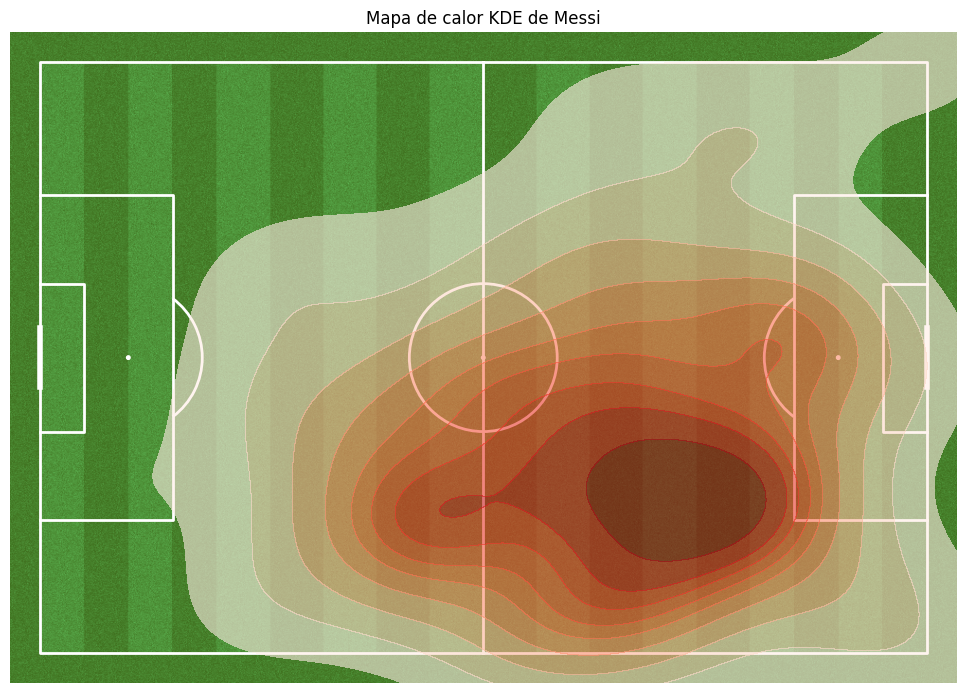

In [17]:
import seaborn as sns

pitch = Pitch(pitch_type='statsbomb', pitch_color='grass', line_color='white', stripe=True)
fig, ax = pitch.draw(figsize=(10, 7))

sns.kdeplot(
    data=messi_loc, x='x', y='y',
    fill=True, cmap='Reds', bw_adjust=1,
    alpha=0.6, ax=ax
)

plt.title('Mapa de calor KDE de Messi')
plt.show()


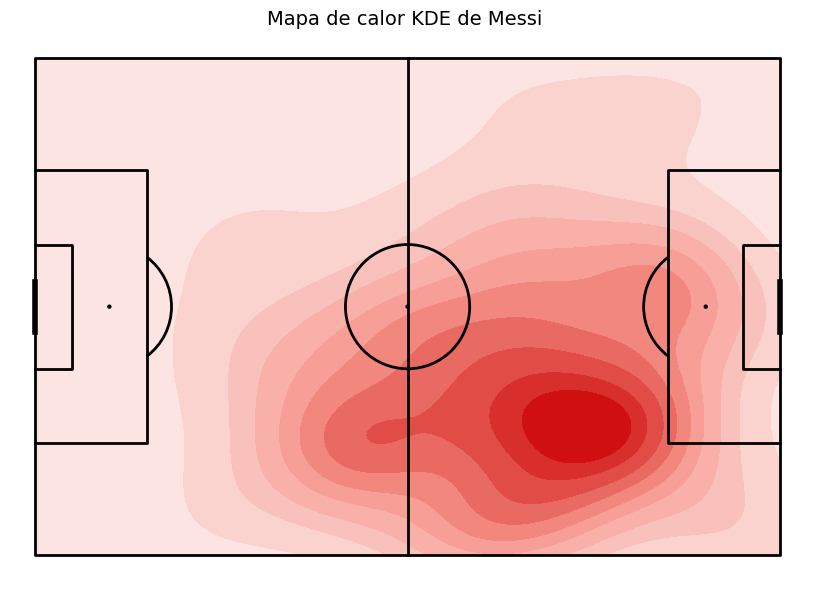

In [18]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from mplsoccer import VerticalPitch
import pandas as pd

# Suponiendo que ya tienes tu DataFrame con columnas 'x' y 'y'
# messi_loc = messi[['x', 'y']]  # Si ya lo generaste

# Puedes definir tu propio colormap (opcional)
flamingo_cmap = LinearSegmentedColormap.from_list(
    "Flamingo", ["#fbe4e2", "#f6968c", "#d01010"], N=10)

pitch = Pitch(pitch_type='statsbomb',  pitch_color='white', line_color='black',line_zorder=2)
fig, ax = pitch.draw(figsize=(10, 6))


# KDE plot con estilo pro
pitch.kdeplot(
    x=messi_loc['x'],
    y=messi_loc['y'],
    ax=ax,
    fill=True,
    levels=100,
    thresh=0,      # para que incluso zonas vacías tengan un poco de color
    cut=1,         # para que el heatmap llegue hasta los bordes
    cmap=flamingo_cmap,
    alpha=1,  # transparencia
    #zorder=1,     # para que el heatmap esté detrás de las líneas del campo
    #bw_adjust=1  # ajuste de suavizado
)

# Título o personalización adicional (opcional)
plt.title('Mapa de calor KDE de Messi ', fontsize=14)
plt.tight_layout()
plt.show()


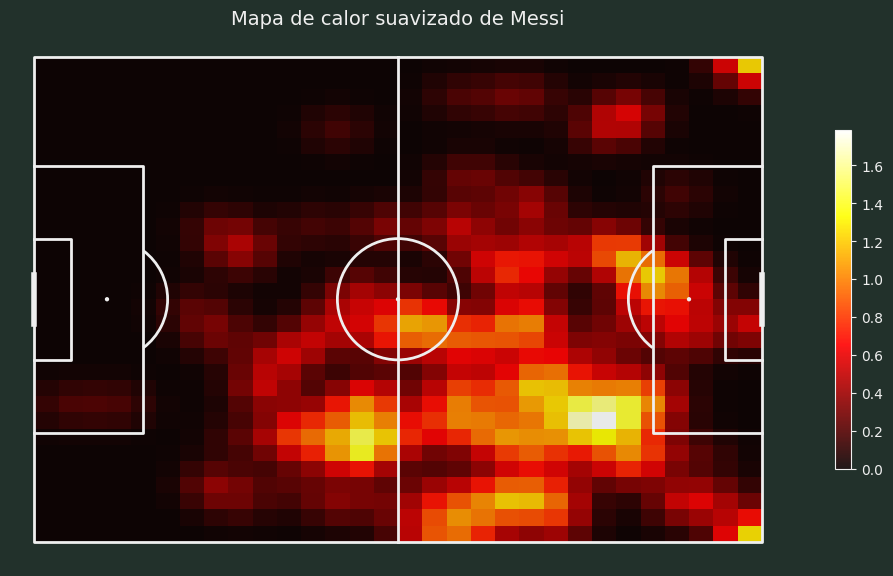

In [90]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import gaussian_filter

from mplsoccer import Pitch

# Supón que ya tienes 'messi_loc' con columnas 'x' y 'y'
# Si no, crea: messi_loc = messi[['x', 'y']]

# Estética de cancha oscura tipo "analista"
pitch = Pitch(pitch_type='statsbomb',
              pitch_color='#22312b', line_color='#efefef', line_zorder=2)

fig, ax = pitch.draw(figsize=(10, 6))
fig.set_facecolor('#22312b')  # fondo externo oscuro también

# Estadística binned (recuento de eventos en celdas)
bin_stat = pitch.bin_statistic(
    x=messi_loc['x'],
    y=messi_loc['y'],
    statistic='count',
    bins=(30, 30)
)

# Suavizado con filtro gaussiano (el número puede ajustarse: más alto = más borroso)
bin_stat['statistic'] = gaussian_filter(bin_stat['statistic'], sigma=1)

# Dibujar el heatmap suavizado
heatmap = pitch.heatmap(
    bin_stat, ax=ax,
    cmap='hot', edgecolors='none' , # bordes del mismo color que el fondo
    alpha=0.9,  # transparencia
)

# Barra de color con estilo elegante
cbar = fig.colorbar(heatmap, ax=ax, shrink=0.6)
cbar.outline.set_edgecolor('#efefef')
cbar.ax.yaxis.set_tick_params(color='#efefef')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='#efefef')

# Título personalizado
plt.title('Mapa de calor suavizado de Messi', color='#efefef', fontsize=14)

plt.show()


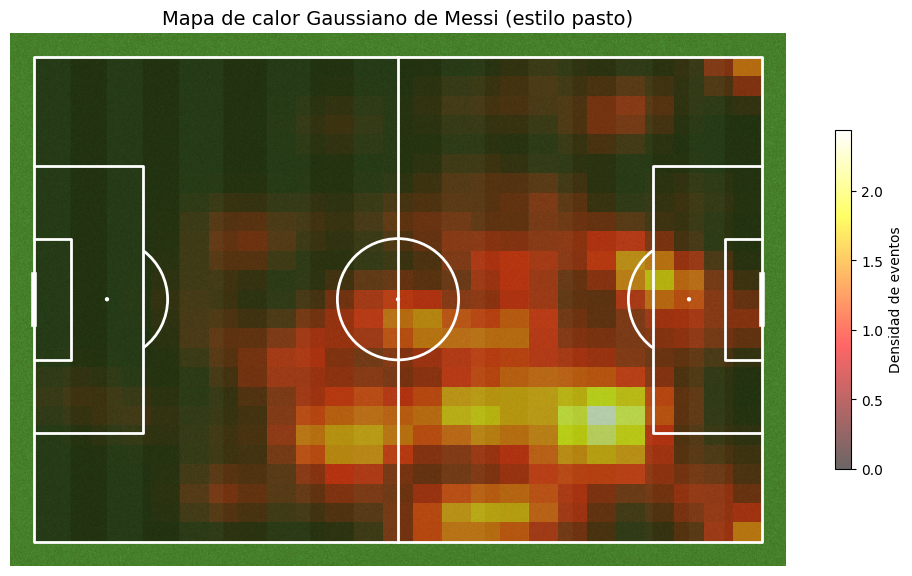

In [87]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import gaussian_filter

from mplsoccer import Pitch

# Supón que ya tienes messi_loc con columnas 'x' y 'y'
# messi_loc = messi[['x', 'y']]

# Estética "grass"
pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='grass',        # 🌱 fondo tipo pasto
    stripe=True,                # opcional: líneas de corte de pasto
    line_color='white',
    line_zorder=2
)

fig, ax = pitch.draw(figsize=(10, 6))

# Bin estadístico (conteo de eventos por zona)
bin_stat = pitch.bin_statistic(
    x=messi_loc['x'],
    y=messi_loc['y'],
    statistic='count',
    bins=(25, 25)
)

# Suavizado gaussiano
bin_stat['statistic'] = gaussian_filter(bin_stat['statistic'], sigma=1)

# Heatmap sobre el pasto 🌶️
heatmap = pitch.heatmap(
    bin_stat,
    ax=ax,
    cmap='hot',             # puedes probar 'Reds', 'magma', etc.
    edgecolors='none',      # sin bordes entre celdas
    alpha=0.6               # ✅ transparencia para ver el pasto debajo
)

# Barra de color
cbar = fig.colorbar(heatmap, ax=ax, shrink=0.6)
cbar.set_label('Densidad de eventos', fontsize=10)

# Título
plt.title('Mapa de calor Gaussiano de Messi (estilo pasto)', fontsize=14)
plt.show()


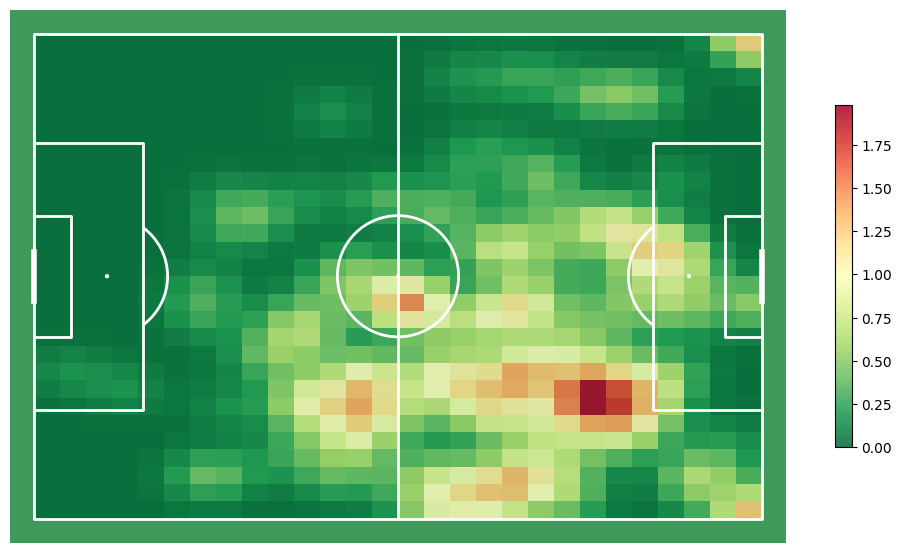

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter
from mplsoccer import Pitch

# Suponiendo que ya tienes el DataFrame messi_loc con columnas 'x' y 'y'
# messi_loc = messi[['x', 'y']]

# 1. Estilo simple y limpio tipo transmisión
pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='#3f995b',    # verde plano tipo app
    line_color='white',
    line_zorder=2,
    linewidth=2
)

fig, ax = pitch.draw(figsize=(10, 6))

# 2. Bins para generar densidad de eventos
bin_stat = pitch.bin_statistic(
    x=messi_loc['x'],
    y=messi_loc['y'],
    statistic='count',
    bins=(28, 28)
)

# 3. Suavizar el heatmap con filtro Gaussiano
bin_stat['statistic'] = gaussian_filter(bin_stat['statistic'], sigma=1)

# 4. Dibujar el heatmap con transparencia
heatmap = pitch.heatmap(
    bin_stat,
    ax=ax,
    cmap='RdYlGn_r',      # reverso: rojo (intenso) → verde (suave)
    edgecolors='none',
    alpha=0.85,
    zorder=1
)
# Barra de color con estilo elegante
cbar = fig.colorbar(heatmap, ax=ax, shrink=0.6)
cbar.outline.set_edgecolor("#000000")
cbar.ax.yaxis.set_tick_params(color="#000000")
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color="#000000")
# 5. Sin colorbar, sin títulos para estilo limpio
plt.tight_layout()
plt.show()
